# Capítulo 5 — Estimação de Parâmetros e Ajuste de Curvas

Este notebook demonstra as principais técnicas de **ajuste de curvas** e **estimação de parâmetros** discutidas no Capítulo 5.

Tópicos:
1. Regressão linear simples (mínimos quadrados)
2. Regressão polinomial
3. Ajuste não-linear com `scipy.optimize.curve_fit`
4. Overfitting vs Underfitting
5. Validação cruzada e escolha do modelo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Regressão Linear Simples

Modelo: $y = \beta_0 + \beta_1 x + \varepsilon$

Estimador de **mínimos quadrados**:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

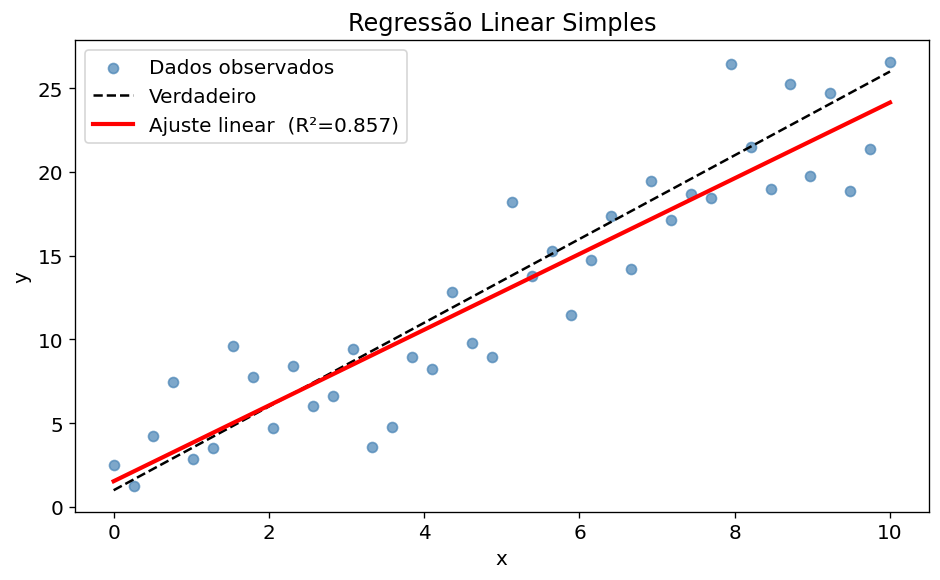

β₀ estimado = 1.538  (verdadeiro = 1.0)
β₁ estimado = 2.261  (verdadeiro = 2.5)
R² = 0.8571


In [2]:
# Dados sintéticos: relação linear com ruído
n = 40
x = np.linspace(0, 10, n)
y_true = 2.5 * x + 1.0
y = y_true + np.random.normal(0, 3, n)

# Ajuste via numpy (mínimos quadrados)
coeffs = np.polyfit(x, y, deg=1)
y_fit = np.polyval(coeffs, x)

# Coeficiente de determinação R²
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, color='steelblue', alpha=0.7, label='Dados observados')
ax.plot(x, y_true, 'k--', lw=1.5, label='Verdadeiro')
ax.plot(x, y_fit, 'r-', lw=2.5, label=f'Ajuste linear  (R²={r2:.3f})')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Regressão Linear Simples')
ax.legend()
plt.tight_layout()
plt.show()

print(f'β₀ estimado = {coeffs[1]:.3f}  (verdadeiro = 1.0)')
print(f'β₁ estimado = {coeffs[0]:.3f}  (verdadeiro = 2.5)')
print(f'R² = {r2:.4f}')

## 2. Regressão Polinomial

Quando a relação entre as variáveis é **não-linear**, podemos ajustar polinômios de grau $d$:
$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

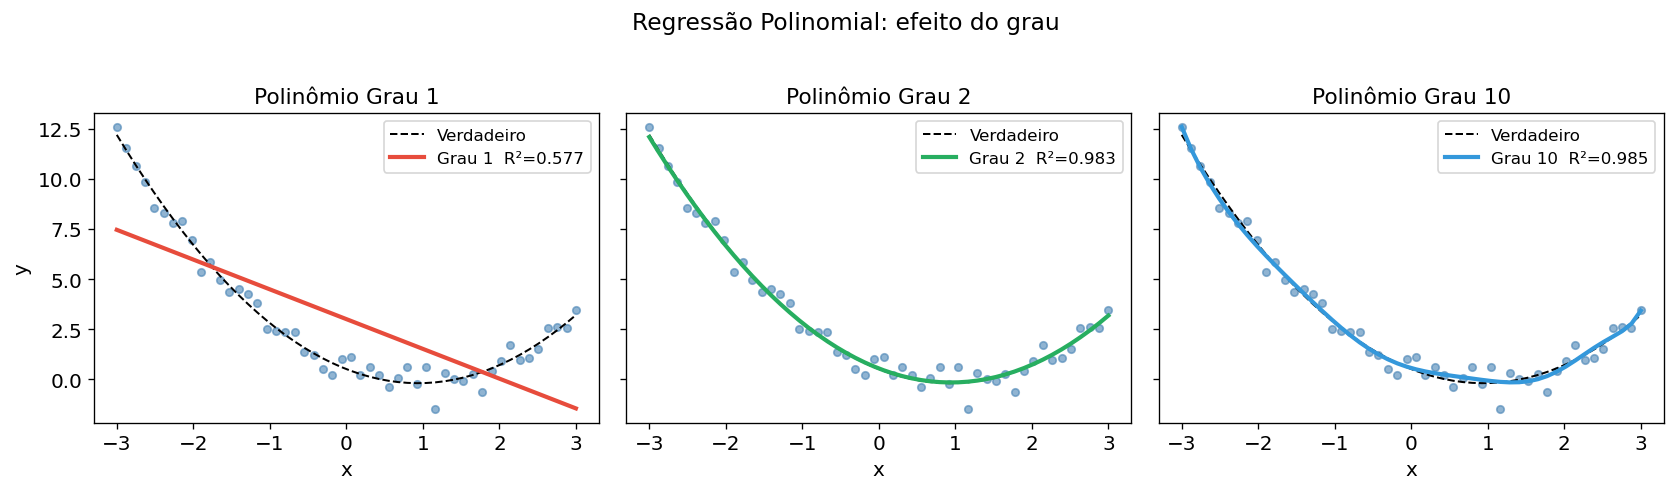

In [3]:
# Dados com relação quadrática
x2 = np.linspace(-3, 3, 50)
y2_true = 0.8 * x2**2 - 1.5 * x2 + 0.5
y2 = y2_true + np.random.normal(0, 0.5, len(x2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
cores = ['#e74c3c', '#27ae60', '#3498db']

for ax, grau, cor in zip(axes, [1, 2, 10], cores):
    coeffs2 = np.polyfit(x2, y2, deg=grau)
    y2_fit = np.polyval(coeffs2, x2)
    ss_res2 = np.sum((y2 - y2_fit)**2)
    ss_tot2 = np.sum((y2 - np.mean(y2))**2)
    r2_g = 1 - ss_res2 / ss_tot2

    ax.scatter(x2, y2, color='steelblue', s=20, alpha=0.6)
    ax.plot(x2, y2_true, 'k--', lw=1.2, label='Verdadeiro')
    ax.plot(x2, y2_fit, color=cor, lw=2.5, label=f'Grau {grau}  R²={r2_g:.3f}')
    ax.set_title(f'Polinômio Grau {grau}', fontsize=13)
    ax.set_xlabel('x')
    ax.legend(fontsize=10)

axes[0].set_ylabel('y')
fig.suptitle('Regressão Polinomial: efeito do grau', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Ajuste Não-linear com `scipy.optimize.curve_fit`

Para funções arbitrárias (ex: cinética enzimática, crescimento exponencial, sigmoide), usamos `curve_fit` que minimiza os resíduos via **Levenberg-Marquardt**.

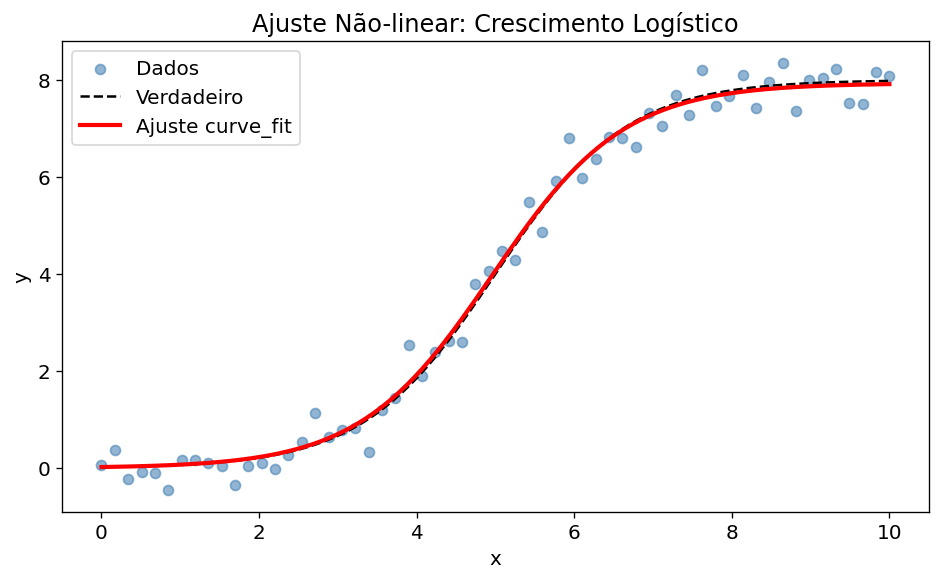

Parâmetros estimados vs verdadeiros:
  L  = 7.933 ± 0.096   (verdadeiro = 8.0)
  k  = 1.193 ± 0.059   (verdadeiro = 1.2)
  x0 = 4.956 ± 0.050   (verdadeiro = 5.0)


In [4]:
# Modelo: crescimento logístico  f(x) = L / (1 + exp(-k*(x - x0)))
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Dados sintéticos
x3 = np.linspace(0, 10, 60)
y3_true = logistic(x3, L=8.0, k=1.2, x0=5.0)
y3 = y3_true + np.random.normal(0, 0.35, len(x3))

# Ajuste
p0 = [7, 1, 5]   # chute inicial
popt, pcov = curve_fit(logistic, x3, y3, p0=p0)
perr = np.sqrt(np.diag(pcov))   # desvio-padrão dos parâmetros

x_plot = np.linspace(0, 10, 200)
y_plot = logistic(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x3, y3, color='steelblue', alpha=0.6, label='Dados')
ax.plot(x_plot, logistic(x_plot, 8.0, 1.2, 5.0), 'k--', lw=1.5, label='Verdadeiro')
ax.plot(x_plot, y_plot, 'r-', lw=2.5, label='Ajuste curve_fit')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Ajuste Não-linear: Crescimento Logístico')
ax.legend()
plt.tight_layout()
plt.show()

print('Parâmetros estimados vs verdadeiros:')
print(f'  L  = {popt[0]:.3f} ± {perr[0]:.3f}   (verdadeiro = 8.0)')
print(f'  k  = {popt[1]:.3f} ± {perr[1]:.3f}   (verdadeiro = 1.2)')
print(f'  x0 = {popt[2]:.3f} ± {perr[2]:.3f}   (verdadeiro = 5.0)')

## 4. Overfitting vs Underfitting

O **erro de treino** diminui sempre com modelos mais complexos. Mas o **erro de teste** (generalização) apresenta um mínimo — o ponto ótimo de complexidade.

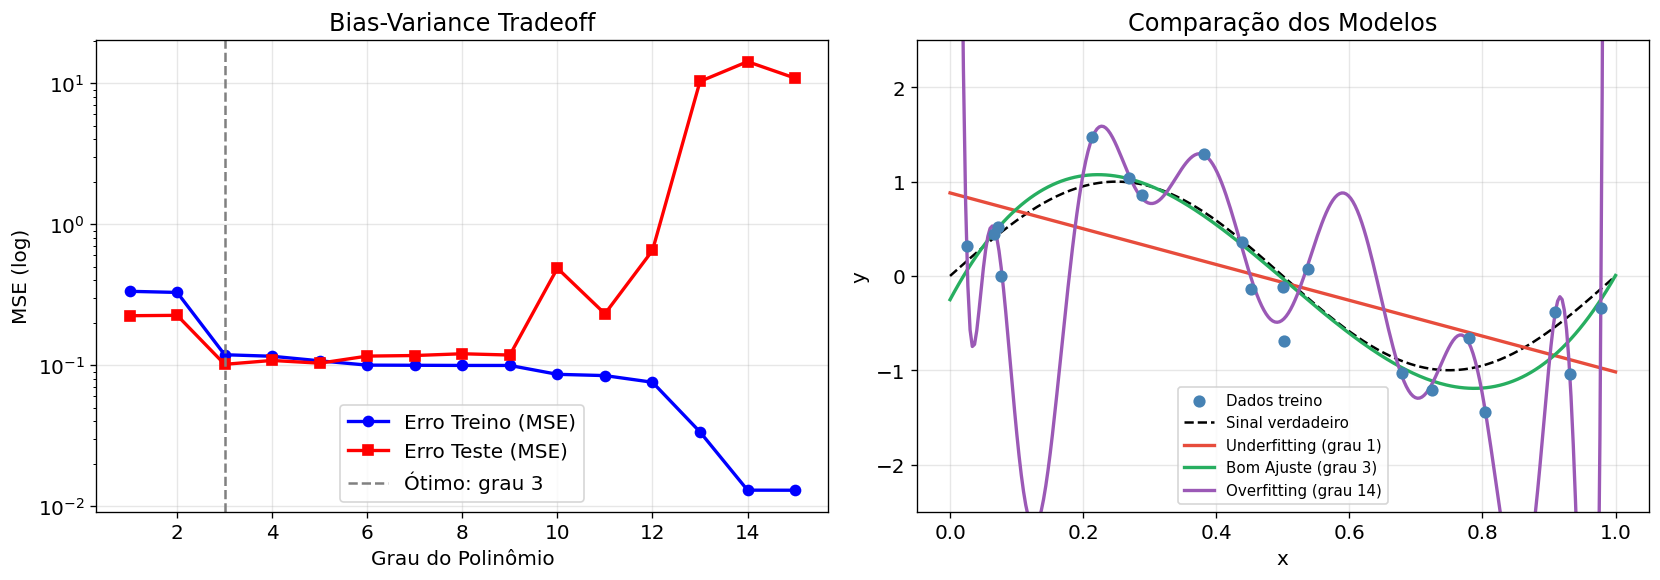

Grau ótimo (menor erro de teste): 3


In [5]:
# Dados de treino e teste
np.random.seed(7)
x_train = np.sort(np.random.uniform(0, 1, 20))
y_train = np.sin(2 * np.pi * x_train) + np.random.normal(0, 0.3, 20)

x_test = np.sort(np.random.uniform(0, 1, 100))
y_test  = np.sin(2 * np.pi * x_test)  + np.random.normal(0, 0.3, 100)

graus = list(range(1, 16))
erros_treino, erros_teste = [], []

for g in graus:
    modelo = make_pipeline(PolynomialFeatures(g), LinearRegression())
    modelo.fit(x_train.reshape(-1,1), y_train)
    erros_treino.append(mean_squared_error(y_train, modelo.predict(x_train.reshape(-1,1))))
    erros_teste.append(mean_squared_error(y_test,  modelo.predict(x_test.reshape(-1,1))))

# Gráfico bias-variance tradeoff
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de erro
ax1.plot(graus, erros_treino, 'b-o', ms=6, lw=2, label='Erro Treino (MSE)')
ax1.plot(graus, erros_teste,  'r-s', ms=6, lw=2, label='Erro Teste (MSE)')
melhor_grau = graus[np.argmin(erros_teste)]
ax1.axvline(melhor_grau, ls='--', color='gray', lw=1.5, label=f'Ótimo: grau {melhor_grau}')
ax1.set_yscale('log')
ax1.set_xlabel('Grau do Polinômio')
ax1.set_ylabel('MSE (log)')
ax1.set_title('Bias-Variance Tradeoff')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Visualização dos ajustes
x_plot2 = np.linspace(0, 1, 300)
cores_ajuste = {'Underfitting (grau 1)': ('#e74c3c', 1),
                f'Bom Ajuste (grau {melhor_grau})': ('#27ae60', melhor_grau),
                'Overfitting (grau 14)': ('#9b59b6', 14)}

ax2.scatter(x_train, y_train, color='steelblue', s=40, zorder=5, label='Dados treino')
ax2.plot(x_plot2, np.sin(2*np.pi*x_plot2), 'k--', lw=1.5, label='Sinal verdadeiro')
for nome, (cor, g) in cores_ajuste.items():
    m = make_pipeline(PolynomialFeatures(g), LinearRegression())
    m.fit(x_train.reshape(-1,1), y_train)
    ax2.plot(x_plot2, m.predict(x_plot2.reshape(-1,1)), color=cor, lw=2, label=nome)
ax2.set_ylim(-2.5, 2.5)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Comparação dos Modelos')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Grau ótimo (menor erro de teste): {melhor_grau}')

## 5. Validação Cruzada (Cross-Validation)

A **validação cruzada** k-fold permite estimar o erro de generalização sem ter um conjunto de teste separado.

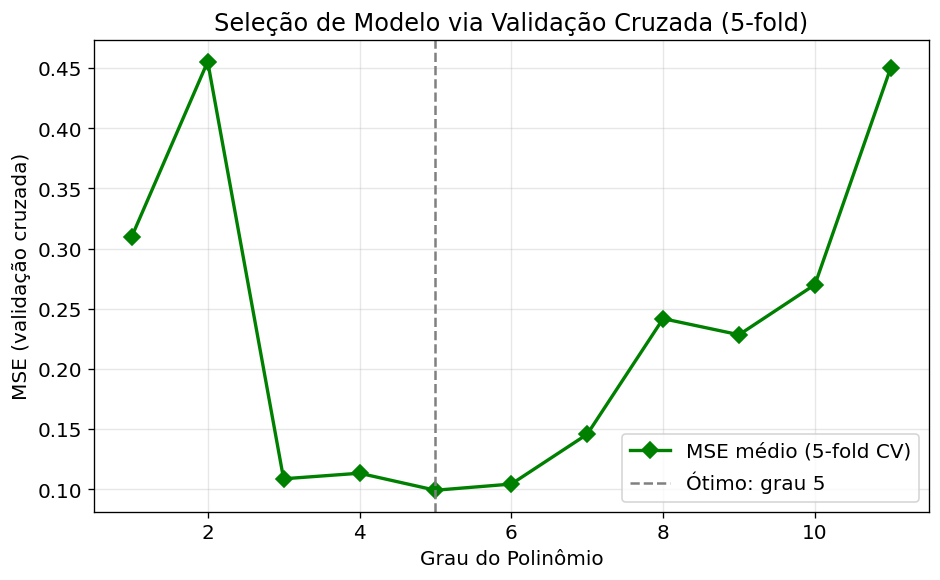

Grau ótimo por CV: 5


In [6]:
graus_cv = list(range(1, 12))
scores_cv = []

X_all = np.concatenate([x_train, x_test]).reshape(-1,1)
y_all = np.concatenate([y_train, y_test])

for g in graus_cv:
    modelo = make_pipeline(PolynomialFeatures(g), LinearRegression())
    cv = cross_val_score(modelo, X_all, y_all, cv=5,
                         scoring='neg_mean_squared_error')
    scores_cv.append(-cv.mean())

melhor_cv = graus_cv[np.argmin(scores_cv)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(graus_cv, scores_cv, 'g-D', ms=7, lw=2, label='MSE médio (5-fold CV)')
ax.axvline(melhor_cv, ls='--', color='gray', lw=1.5, label=f'Ótimo: grau {melhor_cv}')
ax.set_xlabel('Grau do Polinômio')
ax.set_ylabel('MSE (validação cruzada)')
ax.set_title('Seleção de Modelo via Validação Cruzada (5-fold)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Grau ótimo por CV: {melhor_cv}')